# Repository

Het repository pattern vormt een abstractielaag tussen de data layer en business layer, waarbij het de communicatie en datatransformatie regelt.
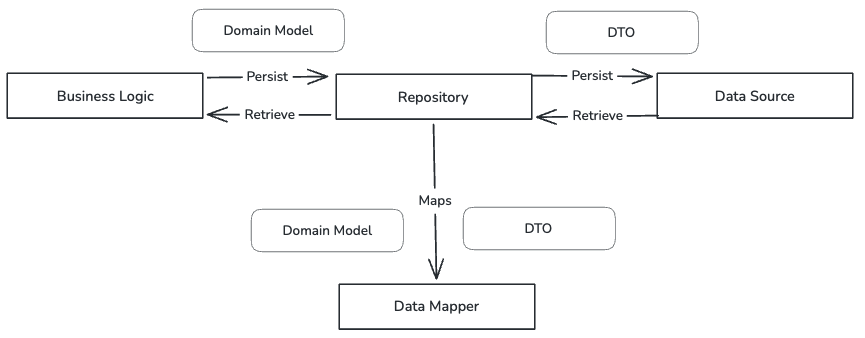

In [7]:
// Domain Model: Bevat logica en gedrag
class User {
    constructor(
        public id: string,
        public name: string,
        public email: string,
        private passwordHash: string
    ) {}

    // Zakelijke logica
    public validatePassword(password: string): boolean {
        return this.passwordHash === `hashed_${password}`;
    }
}

// DTO (Data Transfer Object): Platte data voor de database
interface UserDTO {
    user_id: string;
    full_name: string;
    email_address: string;
    secret_hash: string;
}

// Data Mapper: Vertaalt tussen Domain Model en DTO (en andersom)
class UserDataMapper {
    public static toDTO(domain: User): UserDTO {
        return {
            user_id: domain.id,
            full_name: domain.name,
            email_address: domain.email,
            secret_hash: (domain as any).passwordHash // Interne staat omzetten
        };
    }

    public static toDomain(dto: UserDTO): User {
        return new User(
            dto.user_id,
            dto.full_name,
            dto.email_address,
            dto.secret_hash
        );
    }
}

// Fake Database/DataSource (werkt met DTO's)
class DatabaseDataSource {
    private db = new Map<string, UserDTO>();

    public saveRecord(dto: UserDTO): void {
        this.db.set(dto.user_id, dto);
        console.log(`[DB] Record opgeslagen voor ID: ${dto.user_id}`);
    }

    public findRecord(id: string): UserDTO | undefined {
        return this.db.get(id);
    }
}

// Repository Interface
interface UserRepository {
    persist(user: User): void;
    retrieve(id: string): User | null;
}

// Concrete Repository
class SqlUserRepository implements UserRepository {
    constructor(private dataSource: DatabaseDataSource) {}

    // Persist (Domain -> DTO via Mapper -> Database)
    public persist(user: User): void {
        const dto = UserDataMapper.toDTO(user);
        this.dataSource.saveRecord(dto);
    }

    // Retrieve (Database -> DTO -> Domain via Mapper)
    public retrieve(id: string): User | null {
        const dto = this.dataSource.findRecord(id);
        if (!dto) return null;

        return UserDataMapper.toDomain(dto);
    }
}

// 1. Setup van de infrastructuur
const db = new DatabaseDataSource();
const userRepo: UserRepository = new SqlUserRepository(db);

// 2. Business Logic maakt een Domain object aan
const newUser = new User("1", "Jan Jansen", "jan@example.com", "hashed_geheim123");

// 3. PERSIST: Sla op via Repository
userRepo.persist(newUser);

// 4. RETRIEVE: Haal op via Repository
const retrievedUser = userRepo.retrieve("1");

if (retrievedUser) {
    console.log(`Gebruiker opgehaald: ${retrievedUser.name}`);
    console.log(`Wachtwoord correct? ${retrievedUser.validatePassword("geheim123")}`);
}

[DB] Record opgeslagen voor ID: 1
Gebruiker opgehaald: Jan Jansen
Wachtwoord correct? true
